# PCA from Scratch

The aim of this notebook is to implement **Principal Component Analysis (PCA)** algorithm from scratch using only NumPy.

In [24]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

In [2]:
# Load synthetic dataset
n_samples = 300
X, y_true = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.8, random_state=42)

In [3]:
X.shape, y_true.shape

((300, 2), (300,))

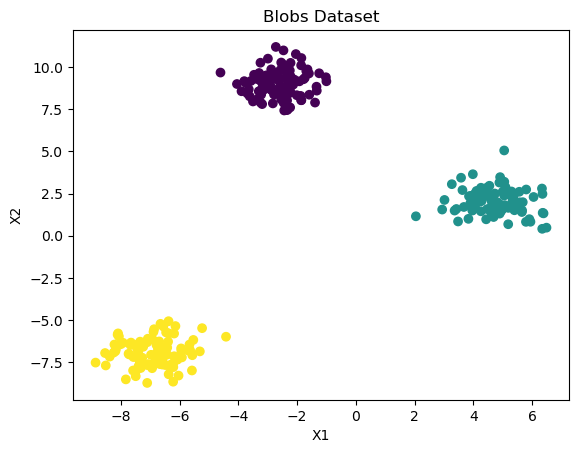

In [4]:
# Visualization
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Blobs Dataset")
plt.show()

By default, `make_blobs` generates features on comparable scales. In a real PCA workflow, the data would have needed to be **standardized** (mean=0, std=1).

In [5]:
# Centering the features
X_mean = np.mean(X, axis=0) # shape (2,)
X_centered = X - X_mean # shape (300, 2)

In [6]:
# Test: ok -> both value are close to zero
np.mean(X_centered, axis=0)

array([-2.96059473e-18,  8.58572472e-17])

In section 2 of `theory.md`, the **covariance** formula is:

$$
C_{ij} = \frac{1}{n-1} \sum_{k=1}^{n} \left(x_i^{(k)} - \mu_i\right)\left(x_j^{(k)} - \mu_j\right)
$$

The terms $(x_i - \mu_i)$ are exactly what `X_centered` contains.

If we use the raw `X`, we compute $$\sum x_i x_j$$ instead of $$\sum (x_i - \mu_i)(x_j - \mu_j)$$

More concretely: covariance measures how two variables vary **around their mean**.

Without subtracting the mean, we mix the variance with the absolute position of the data in space, the result no longer has a proper statistical meaning.

In [7]:
# Covariance matrix
C = (1/(n_samples-1)) * X_centered.T @ X_centered

In [8]:
C.shape # ok, with 2 the number of features

(2, 2)

The diagonal of C contains the **variances of each individual feature**.

In [9]:
print("Covariance matrix,\nC=", C)

Covariance matrix,
C= [[23.6668723  13.48616967]
 [13.48616967 43.62590244]]


Consistent: symmetric matrix, positive variances, positive off-diagonal covariance (the two features vary in the same direction)

In [10]:
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(C)
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

In [11]:
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:", eigenvectors)

Eigenvalues: [50.42338035 16.86939439]
Eigenvectors: [[ 0.45009257 -0.8929819 ]
 [ 0.8929819   0.45009257]]


The **first eigenvalue** represents the **variance of the data projected onto this direction**: we can verify that 50.42 + 16.87 ≈ 67.29 = the trace of C (23.67 + 43.63). The trace remains unchanged, which is a good test of the model’s soundness.

The **first eigenvector** [0.45, 0.89] (1st column) points in the **direction of maximum variance**, more oriented toward feature 2 (coefficient 0.89) than feature 1 (0.45).

In [12]:
# Keeping first k components
k = 1
W = eigenvectors[:, :k]

In [13]:
W.shape # ok

(2, 1)

In [14]:
print("W=", W)

W= [[0.45009257]
 [0.8929819 ]]


In [15]:
# Projection the data into the new subspace
Z = X_centered @ W

In [16]:
Z.shape # ok, 300 samples and 1 component, 2D -> 1D reduction done

(300, 1)

In [17]:
# Explained variance ratio
ratio = eigenvalues / eigenvalues.sum()

In [18]:
# Cumulative explained variance 
cumulative = np.cumsum(ratio)

In [19]:
print("Explained Variance Ratio =", ratio)
print("Cumulative Explained Variance =", cumulative)

Explained Variance Ratio = [0.74931344 0.25068656]
Cumulative Explained Variance = [0.74931344 1.        ]


Explained variance ratios values are the **principal components**.

- PC1 accounts for 74.9% of the total variance in the data
- PC2 accounts for 25.1%, the remainder
- Total: 100% (which makes sense, since we’ve kept all the components here)

So with k=1, we retain **75% of the information**. 

With k=2, we retain 100% because we haven’t reduced the dimensionality at all.

In a real dataset with 50 features, we look for the **point where the cumulative percentage exceeds your target threshold** (e.g., 95%) with as few components as possible.

Here, 75% for k=1 is correct but not exceptional, this is because `make_blobs` generates relatively isotropic data. On data with strong correlation between features, PC1 often captures 90%+.

In [20]:
# Reconstruction
X_rebuilt = Z @ W.T + X_mean

In [21]:
# Reconstruction error (Frobenius norm)
reconstruction_error = (1/n_samples) * np.linalg.norm(X - X_rebuilt, 'fro') ** 2

In [22]:
print("Reconstruction error =", reconstruction_error)

Reconstruction error = 16.81316307280355


In [23]:
eigenvalues.sum() * 0.251

np.float64(16.89048645812487)

The **total variance of the data = sum of the eigenvalues**. 

**PC1 accounts for 74.9% of this variance** → the remaining 25.1% is the reconstruction error. 

The small difference (16.81 vs. 16.89) stems from the fact that the covariance uses n-1, but the error uses n.

So reconstruction_error = 16.81 means that the average variance per sample that is not captured by k=1. It is not an absolute figure, it should always be interpreted proportionally: 25% of the total variance is lost.

In [25]:
# Scikit-Learn comparison
pca = PCA(n_components=1)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",1
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [27]:
# W comparison (eigenvector)
print("Sklearn components_ =", pca.components_)
print("Scratch W.T         =", W.T)

Sklearn components_ = [[0.45009257 0.8929819 ]]
Scratch W.T         = [[0.45009257 0.8929819 ]]


In [28]:
# Explained variance ratio comparison
print("Sklearn Explained Variance Ratio =", pca.explained_variance_ratio_)
print("Scratch Explained Variance Ratio =", ratio[0])

Sklearn Explained Variance Ratio = [0.74931344]
Scratch Explained Variance Ratio = 0.7493134373754102


In [29]:
# Projected data comparison (first 5 rows)
Z_sklearn = pca.transform(X)
print("Sklearn Z[:5] =", Z_sklearn[:5].flatten())
print("Scratch Z[:5] =", Z[:5].flatten())

Sklearn Z[:5] = [-10.51153225 -10.32354524   5.84551787   4.05821937 -11.19304983]
Scratch Z[:5] = [-10.51153225 -10.32354524   5.84551787   4.05821937 -11.19304983]


Perfect validation: eigenvectors, explained variance ratio, and projections are identical to within a floating-point precision.